### Import das Classes

In [104]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP3 import ProblemaP3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Problema 3

No problema 3, reaproveitamos o sorteio de obstruções do problema 2, mas a condição de contorno muda.

Agora fixamos uma pressão de entrada `P_in` nos nós de fonte e verificamos se a rede consegue manter pressão suficiente nos demais nós.

O objetivo é encontrar a menor frequência de limpeza para que a probabilidade de falha seja menor que `x`.

A falha usada no código é:

$$
\min_{i \in \mathcal{C}} p_i < P_{min}
$$

onde $\mathcal{C}$ é o conjunto de nós monitorados, sem incluir os nós de entrada com pressão prescrita.


### Gerando a rede base do P1

In [105]:
generator = ProblemaP1Generator(seed=42)  # fixa a aleatoriedade

prob = generator.generate(
    num_nodes=100,      # numero de nos da rede
    edge_prob=0.25,     # chance de criar aresta entre dois nos
    mu=1e-3,            # viscosidade da agua em pa s
    patm=0.0,           # pressao de referencia usada no p1
    q_mode="uniform",   # distribui as vazoes de forma uniforme
    single_sink=True    # usa apenas um no de saida
)

prob.setup()  # monta as matrizes do problema
prob.solve()  # resolve o p1 apenas para visualizar a rede base

print("P1 resolvido para visualizacao")
print("pressao minima no p1:", np.min(prob.p))
print("pressao maxima no p1:", np.max(prob.p))


P1 resolvido para visualizacao
pressao minima no p1: 0.0
pressao maxima no p1: 0.009147588241158675


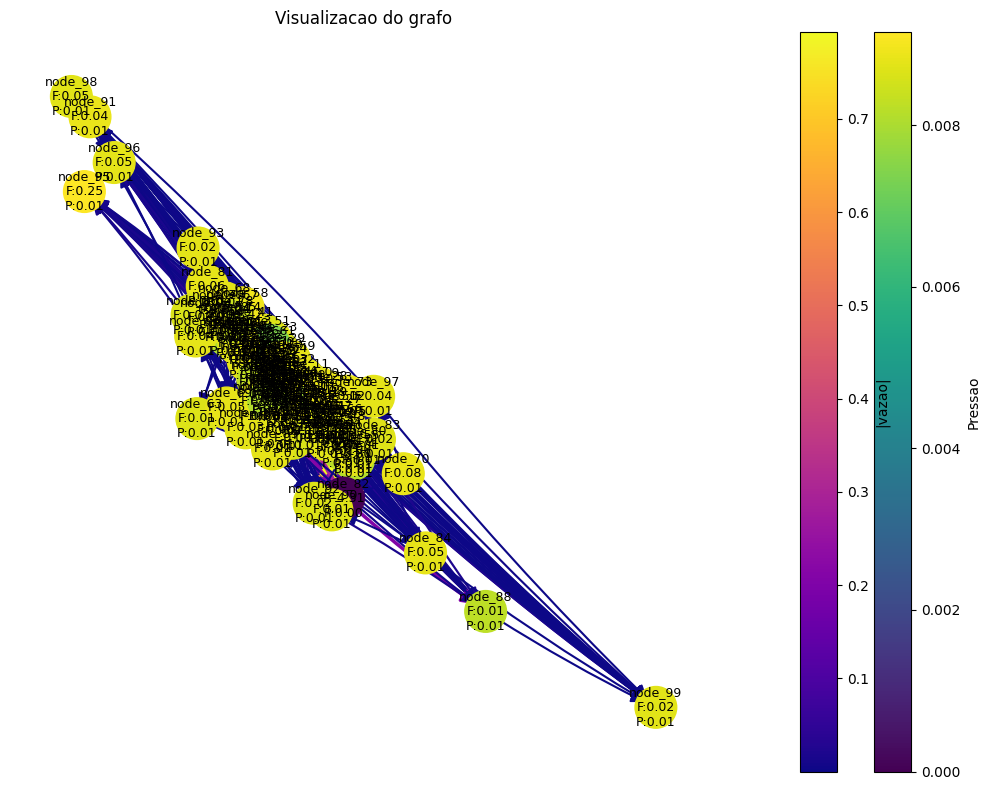

In [106]:
prob.plot(
    show_edge_labels=False,
    show_node_labels=True,
    layout='spring',
    node_value_attr='pressao',
    edge_value_attr='vazao'
)

### Tabela de manutenção do P3

In [107]:
pd.DataFrame(ProblemaP3.DEFAULT_MAINTENANCE_TABLE)

,frequencia,r_prob,custo
0,1,0.25,5.0
1,2,0.10,10.0
2,3,0.06,15.0
3,4,0.04,20.0
4,6,0.03,30.0
5,8,0.02,40.0
6,12,0.01,60.0


### Parâmetros do P3

In [111]:
alpha = 2.0    # resistencia dobra quando o cano esta obstruido
P_in = 1.0     # pressao fixa nos nos de entrada
P_min = 0.9915  # pressao minima admissivel nos nos monitorados
x = 0.05       # probabilidade maxima de falha aceita, 5%
N = 1000       # numero de simulacoes de monte carlo
seed = 42      # fixa a aleatoriedade


### Criando o problema probabilístico inverso

In [112]:
p3 = ProblemaP3(
    p1_instance=prob,  # problema p1 ja montado
    alpha=alpha,       # fator de obstrucao
    P_in=P_in,         # pressao fixa nos nos de entrada
    P_min=P_min,       # pressao minima admissivel
    x=x,               # risco maximo aceito
    n_samples=N,       # numero de simulacoes
    seed=seed          # fixa a aleatoriedade
)


### Rodando o P3

In [113]:
best, results = p3.solve_inverse_problem(
    n_iter=N,           # simulacoes por frequencia
    confidence=0.95,    # nivel do intervalo de confianca
    seed=seed,          # fixa a aleatoriedade
    use_upper_ci=False  # usa a probabilidade estimada como criterio
)

### Resultados por frequência

In [114]:
df = pd.DataFrame([
    {k: v for k, v in row.items() if k != "node_failure_probability"}
    for row in results
])

cols = [
    "frequencia",
    "r_prob",
    "custo",
    "P_in",
    "P_min",
    "P_fail",
    "IC_lower",
    "IC_upper",
    "mean_min_pressure",
    "std_min_pressure",
    "min_pressure_observed",
    "accepted",
]

df_resultados = df[[col for col in cols if col in df.columns]]
df_resultados


,frequencia,r_prob,custo,P_in,P_min,P_fail,IC_lower,IC_upper,mean_min_pressure,std_min_pressure,min_pressure_observed,accepted
0,1,0.25,5.0,1.0,0.9915,0.845,0.822569,0.867431,0.990749,0.000762,0.987835,False
1,2,0.10,10.0,1.0,0.9915,0.371,0.341059,0.400941,0.991506,0.000436,0.989832,False
2,3,0.06,15.0,1.0,0.9915,0.207,0.181889,0.232111,0.991685,0.000339,0.989970,False
3,4,0.04,20.0,1.0,0.9915,0.114,0.094302,0.133698,0.991777,0.000271,0.990292,False
4,6,0.03,30.0,1.0,0.9915,0.080,0.063185,0.096815,0.991821,0.000232,0.990292,False
5,8,0.02,40.0,1.0,0.9915,0.049,0.035621,0.062379,0.991864,0.000186,0.990799,True
6,12,0.01,60.0,1.0,0.9915,0.026,0.016137,0.035863,0.991902,0.000138,0.991006,True


### Checagem de coerência

Com pressão de entrada fixa, o esperado é que a probabilidade de falha diminua quando a frequência aumenta, pois `r_prob` diminui.


In [115]:
df_resultados[["frequencia", "r_prob", "P_fail", "mean_min_pressure", "accepted"]]


,frequencia,r_prob,P_fail,mean_min_pressure,accepted
0,1,0.25,0.845,0.990749,False
1,2,0.10,0.371,0.991506,False
2,3,0.06,0.207,0.991685,False
3,4,0.04,0.114,0.991777,False
4,6,0.03,0.080,0.991821,False
5,8,0.02,0.049,0.991864,True
6,12,0.01,0.026,0.991902,True


### Resposta do problema

In [116]:
if best is None:
    print("Nenhuma frequencia da tabela satisfaz o criterio.")
else:
    print("frequencia minima:", best["frequencia"], "vezes por ano")
    print("r:", best["r_prob"])
    print("custo:", best["custo"], "kR$")
    print("probabilidade de falha:", best["P_fail"])
    print("intervalo de confianca:", (best["IC_lower"], best["IC_upper"]))

frequencia minima: 8 vezes por ano
r: 0.02
custo: 40.0 kR$
probabilidade de falha: 0.049
intervalo de confianca: (0.03562060765260524, 0.062379392347394765)


### Gráfico da probabilidade de falha

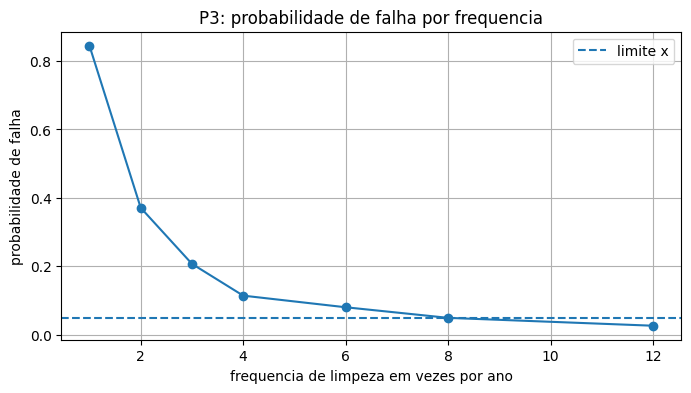

In [117]:
plt.figure(figsize=(8, 4))
plt.plot(df["frequencia"], df["P_fail"], marker="o")
plt.axhline(x, linestyle="--", label="limite x")
plt.xlabel("frequencia de limpeza em vezes por ano")
plt.ylabel("probabilidade de falha")
plt.title("P3: probabilidade de falha por frequencia")
plt.grid(True)
plt.legend()
plt.show()

### Gráfico do custo

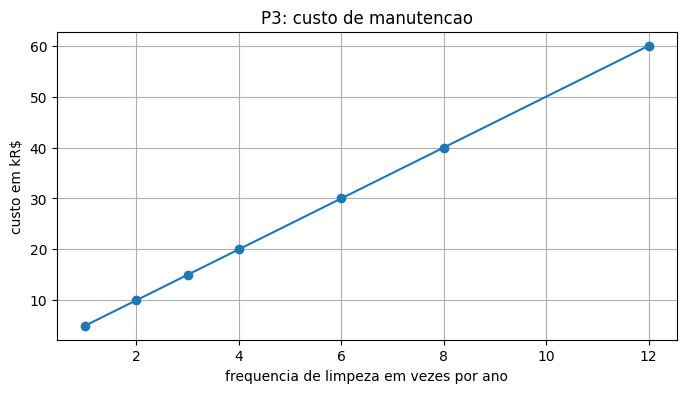

In [118]:
plt.figure(figsize=(8, 4))
plt.plot(df["frequencia"], df["custo"], marker="o")
plt.xlabel("frequencia de limpeza em vezes por ano")
plt.ylabel("custo em kR$")
plt.title("P3: custo de manutencao")
plt.grid(True)
plt.show()

### Resumo

In [119]:
p3.summary()

{'P_in': 1.0,
 'P_min': 0.9915,
 'x': 0.05,
 'best_solution': {'frequencia': 8,
  'r_prob': 0.02,
  'custo': 40.0,
  'P_in': 1.0,
  'P_min': 0.9915,
  'x': 0.05,
  'criterion': 'P_fail',
  'criterion_value': 0.049,
  'accepted': True,
  'n_samples': 1000,
  'P_fail': 0.049,
  'IC_lower': 0.03562060765260524,
  'IC_upper': 0.062379392347394765,
  'mean_min_pressure': 0.9918642992904226,
  'std_min_pressure': 0.00018591286393546605,
  'min_pressure_observed': 0.9907990064422776,
  'node_failure_probability': {'node_82': 0.049}},
 'critical_r': 0.02,
 'results': [{'frequencia': 1,
   'r_prob': 0.25,
   'custo': 5.0,
   'P_in': 1.0,
   'P_min': 0.9915,
   'x': 0.05,
   'criterion': 'P_fail',
   'criterion_value': 0.845,
   'accepted': False,
   'n_samples': 1000,
   'P_fail': 0.845,
   'IC_lower': 0.8225693274946912,
   'IC_upper': 0.8674306725053087,
   'mean_min_pressure': 0.9907492939897793,
   'std_min_pressure': 0.0007623769917740756,
   'min_pressure_observed': 0.9878347415028688,
  

### Conclusão

O P3 usa a mesma rede do P1 e o mesmo sorteio de obstruções do P2, mas muda a condição de contorno: a pressão é fixada nos nós de entrada.

Para cada frequência de limpeza, o código usa o valor correspondente de `r_prob`, roda Monte Carlo e estima a probabilidade de algum nó monitorado ficar com pressão abaixo de `P_min`.

A solução é a primeira frequência da tabela que satisfaz:

$$
\widehat{P}_f < x
$$

Se a tabela estiver coerente, `P_fail` deve diminuir quando a frequência aumenta.
